In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as snp
import numpy as np

In [ ]:
transaction=pd.read_excel("/content/sample_data/QVI_transaction_data.xlsx")
purchase = pd.read_csv("/content/sample_data/QVI_purchase_behaviour.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/QVI_transaction_data.xlsx'

In [ ]:
transaction.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [ ]:
transaction.tail()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8
264835,43365,272,272380,270189,74,Tostitos Splash Of Lime 175g,2,8.8


In [ ]:
transaction.shape

(264836, 8)

In [ ]:
transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [ ]:
print(transaction.columns.tolist())

['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES']


OPERATION_1 CONVERTING DATE INTO DATE FORMAT

In [ ]:
print(transaction['DATE'].head(10))

0    43390
1    43599
2    43605
3    43329
4    43330
5    43604
6    43601
7    43601
8    43332
9    43330
Name: DATE, dtype: int64


In [ ]:
print(transaction['DATE'].dtype)

int64


In [ ]:
transaction['DATE'].dtype

dtype('int64')

In [ ]:
transaction['DATE']=pd.to_datetime(transaction['DATE'],origin='1899-12-30',unit='D')

In [ ]:
transaction['DATE'].head(10)

,DATE
0,2018-10-17
1,2019-05-14
2,2019-05-20
3,2018-08-17
4,2018-08-18
5,2019-05-19
6,2019-05-16
7,2019-05-16
8,2018-08-20
9,2018-08-18


In [ ]:
transaction['DATE'].dtype

dtype('<M8[ns]')

In [ ]:
transaction.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
5,2019-05-19,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
8,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,2018-08-18,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2


OPERATION_2 REMOVING THE NON CHIPS PRODUCTS

In [ ]:
print(transaction['PROD_NAME'].unique())

['Natural Chip        Compny SeaSalt175g' 'CCs Nacho Cheese    175g'
 'Smiths Crinkle Cut  Chips Chicken 170g'
 'Smiths Chip Thinly  S/Cream&Onion 175g'
 'Kettle Tortilla ChpsHny&Jlpno Chili 150g'
 'Old El Paso Salsa   Dip Tomato Mild 300g'
 'Smiths Crinkle Chips Salt & Vinegar 330g'
 'Grain Waves         Sweet Chilli 210g'
 'Doritos Corn Chip Mexican Jalapeno 150g'
 'Grain Waves Sour    Cream&Chives 210G'
 'Kettle Sensations   Siracha Lime 150g' 'Twisties Cheese     270g'
 'WW Crinkle Cut      Chicken 175g' 'Thins Chips Light&  Tangy 175g'
 'CCs Original 175g' 'Burger Rings 220g'
 'NCC Sour Cream &    Garden Chives 175g'
 'Doritos Corn Chip Southern Chicken 150g' 'Cheezels Cheese Box 125g'
 'Smiths Crinkle      Original 330g'
 'Infzns Crn Crnchers Tangy Gcamole 110g'
 'Kettle Sea Salt     And Vinegar 175g'
 'Smiths Chip Thinly  Cut Original 175g' 'Kettle Original 175g'
 'Red Rock Deli Thai  Chilli&Lime 150g' 'Pringles Sthrn FriedChicken 134g'
 'Pringles Sweet&Spcy BBQ 134g' 'Red Rock 

In [ ]:
transaction = transaction [~transaction['PROD_NAME'].str.contains('salsa',case=False)]

In [ ]:
print(type(transaction))

<class 'pandas.core.frame.DataFrame'>


OPERATION_3 EXTRACTING PACKSIZE FROM PRODUCT_NAME

In [ ]:
transaction.head(20)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
8,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,2018-08-18,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2
10,2019-05-17,7,7215,7176,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7


In [ ]:
transaction['PACK_SIZE']=transaction['PROD_NAME'].str.extract(r'(\d+)[Gg]')

In [ ]:
transaction['PACK_SIZE']=transaction['PACK_SIZE'].astype(int)

In [ ]:
transaction.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE'],
      dtype='object')

In [ ]:
transaction.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150


OPERATION_3 CHECKING AND REMOVING THE OUTLIERS FROM PRODUCT_QUANTITY AND TOTAL_SALES

In [ ]:
transaction['TOT_SALES'].describe()

,TOT_SALES
count,246742.000000
mean,7.321322
std,3.077828
min,1.700000
25%,5.800000
50%,7.400000
75%,8.800000
max,650.000000


In [ ]:
transaction['PROD_QTY'].describe()

,PROD_QTY
count,246742.000000
mean,1.908062
std,0.659831
min,1.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,200.000000


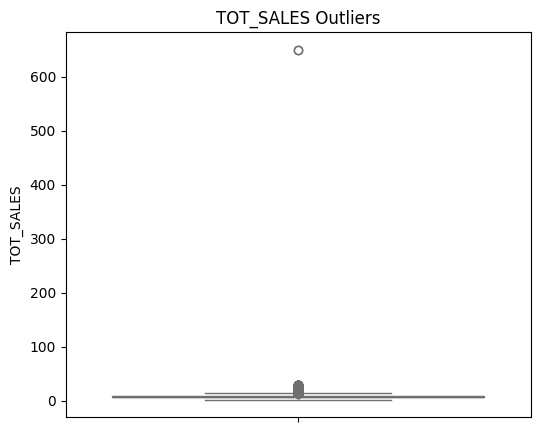

In [ ]:
plt.figure(figsize=(6, 5))
snp.boxplot(y=transaction['TOT_SALES'], color='skyblue')
plt.title('TOT_SALES Outliers')
plt.show()

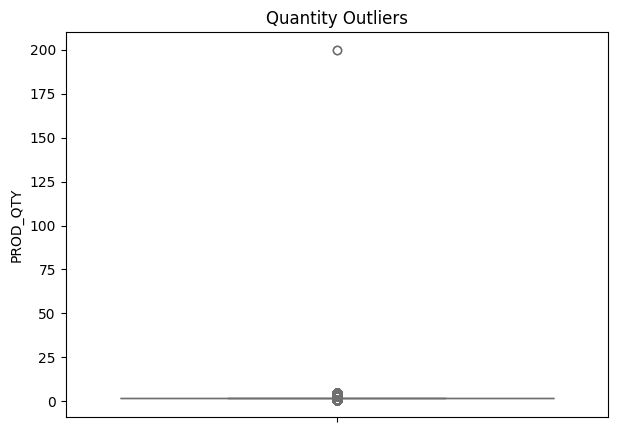

In [ ]:
plt.figure(figsize=(7,5))
snp.boxplot(y=transaction['PROD_QTY'],color='skyblue')
plt.title("Quantity Outliers")
plt.show()

In [ ]:
print("Before:", transaction.shape)

Before: (246742, 9)


In [ ]:
q1 = transaction['TOT_SALES'].quantile(0.25)
q3 = transaction['TOT_SALES'].quantile(0.75)
IQR=q3-q1
lower=q1-1.5*IQR
upper=q3+1.5*IQR
transaction=transaction[(transaction['TOT_SALES']>=lower)  & (transaction['TOT_SALES']<=upper)]

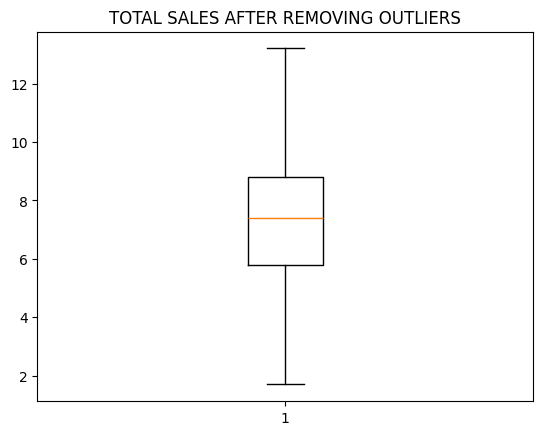

In [ ]:
plt.boxplot(transaction['TOT_SALES'])
plt.title("TOTAL SALES AFTER REMOVING OUTLIERS")
plt.show()

In [ ]:
transaction['PROD_QTY'].describe()

,PROD_QTY
count,246073.000000
mean,1.899745
std,0.315466
min,1.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,5.000000


In [ ]:
Q1 = transaction['TOT_SALES'].quantile(0.25)
Q3 = transaction['TOT_SALES'].quantile(0.75)
IQR = Q3 - Q1
transaction = transaction[
    (transaction['TOT_SALES'] >= Q1 - 1.5 * IQR) &
    (transaction['TOT_SALES'] <= Q3 + 1.5 * IQR)
]

# ── Remove Outliers PROD_QTY using Common Sense ───
transaction = transaction[transaction['PROD_QTY'] < 200]


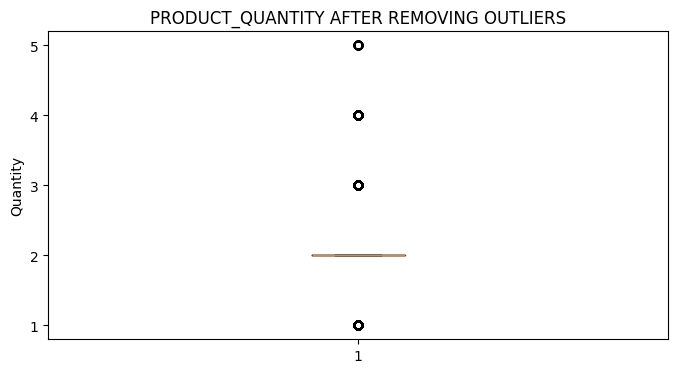

In [ ]:
plt.figure(figsize=(8,4))
plt.boxplot(transaction['PROD_QTY'])
plt.title("PRODUCT_QUANTITY AFTER REMOVING OUTLIERS")
plt.ylabel("Quantity")
plt.yticks([1,2,3,4,5])
plt.show()

In [ ]:
print(transaction['PROD_QTY'].value_counts().sort_index())
print("Max:", transaction['PROD_QTY'].max())
print("Min:", transaction['PROD_QTY'].min())

PROD_QTY
1     25476
2    220070
3       309
4       157
5        61
Name: count, dtype: int64
Max: 5
Min: 1


TABLE_2 CHECKING AND EXPLORING

In [ ]:
purchase.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [ ]:
purchase.isnull().sum()

,0
LYLTY_CARD_NBR,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


In [ ]:
purchase.value_counts('LIFESTAGE').sum()

np.int64(72637)

In [ ]:
purchase.shape

(72637, 3)

In [ ]:
purchase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [ ]:
print(purchase['PREMIUM_CUSTOMER'].value_counts())

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64


In [ ]:
merged = transaction.merge(purchase, on='LYLTY_CARD_NBR', how='inner')

In [ ]:
print(merged.shape)
print(merged.head())
print(merged.columns.tolist())

(246073, 11)
        DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0 2018-10-17          1            1000       1         5   
1 2019-05-14          1            1307     348        66   
2 2019-05-20          1            1343     383        61   
3 2019-05-16          4            4149    3333        16   
4 2019-05-16          4            4196    3539        24   

                                  PROD_NAME  PROD_QTY  TOT_SALES  PACK_SIZE  \
0    Natural Chip        Compny SeaSalt175g         2        6.0        175   
1                  CCs Nacho Cheese    175g         3        6.3        175   
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9        170   
3  Smiths Crinkle Chips Salt & Vinegar 330g         1        5.7        330   
4     Grain Waves         Sweet Chilli 210g         1        3.6        210   

                LIFESTAGE PREMIUM_CUSTOMER  
0   YOUNG SINGLES/COUPLES          Premium  
1  MIDAGE SINGLES/COUPLES           Budget  
2  MIDAGE 

In [ ]:
merged.to_csv('QVI_merged_data.csv', index=False)
print("File saved successfully!")

File saved successfully!


In [ ]:
from google.colab import files
files.download('QVI_merged_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

VISUALIZATION

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as snp
import numpy as np

In [ ]:
dt=pd.read_csv("/content/QVI_merged_data_quantum.csv")

In [ ]:
dt.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,MIDAGE SINGLES/COUPLES,Budget
3,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330,MIDAGE SINGLES/COUPLES,Budget
4,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,210,MIDAGE SINGLES/COUPLES,Budget


In [ ]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246073 entries, 0 to 246072
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATE              246073 non-null  object 
 1   STORE_NBR         246073 non-null  int64  
 2   LYLTY_CARD_NBR    246073 non-null  int64  
 3   TXN_ID            246073 non-null  int64  
 4   PROD_NBR          246073 non-null  int64  
 5   PROD_NAME         246073 non-null  object 
 6   PROD_QTY          246073 non-null  int64  
 7   TOT_SALES         246073 non-null  float64
 8   PACK_SIZE         246073 non-null  int64  
 9   LIFESTAGE         246073 non-null  object 
 10  PREMIUM_CUSTOMER  246073 non-null  object 
dtypes: float64(1), int64(6), object(4)
memory usage: 20.7+ MB


In [ ]:
segment_sales=dt.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOT_SALES'].sum().sort_values(ascending=False)

In [ ]:
segment_sales

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Budget              155728.55
YOUNG SINGLES/COUPLES   Mainstream          146796.20
RETIREES                Mainstream          144449.55
YOUNG FAMILIES          Budget              128785.50
OLDER SINGLES/COUPLES   Budget              126828.20
                        Mainstream          123748.10
                        Premium             122639.65
RETIREES                Budget              105117.60
OLDER FAMILIES          Mainstream           95536.90
RETIREES                Premium              90715.30
YOUNG FAMILIES          Mainstream           85591.55
MIDAGE SINGLES/COUPLES  Mainstream           84087.70
YOUNG FAMILIES          Premium              78039.70
OLDER FAMILIES          Premium              74591.60
YOUNG SINGLES/COUPLES   Budget               56862.50
MIDAGE SINGLES/COUPLES  Premium              54112.65
YOUNG SINGLES/COUPLES   Premium              38888.20
MIDAGE SINGLES/COUPLES  Budget               33097.00
NEW FAMILIES            Budget               20526.85
                        Mainstream           15921.45
                        Premium              10720.20
Name: TOT_SALES, dtype: float64

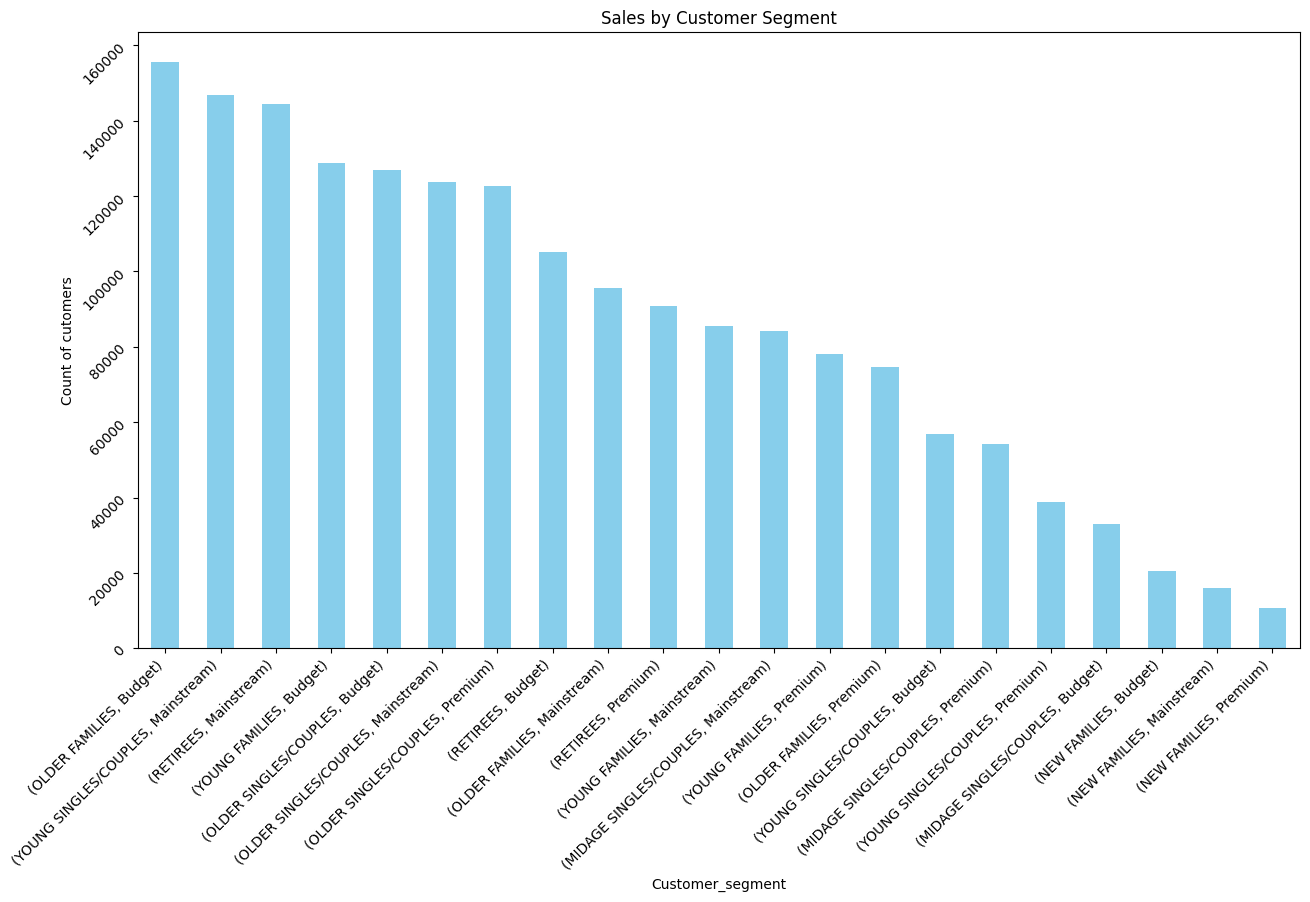

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(15,8))
segment_sales.plot(kind='bar',color='skyblue',width=0.5)
plt.xlabel("Customer_segment")
plt.ylabel("Count of cutomers")
plt.title('Sales by Customer Segment')
plt.xticks(rotation=45,ha='right')
plt.yticks(rotation=45)
plt.show()
plt.savefig("sales_customer.segemnt.jpg",dpi=400,bbox_inches='tight')

In [ ]:
dt.shape

(246073, 11)

In [ ]:
dt=pd.read_csv("/content/QVI_merged_data_quantum.csv")
top_products=dt.groupby('PROD_NAME')['TOT_SALES'].sum().sort_values(ascending=False).head(10).reset_index()

In [ ]:
top_products

,PROD_NAME,TOT_SALES
0,Dorito Corn Chp Supreme 380g,38918.75
1,Smiths Crnkle Chip Orgnl Big Bag 380g,35907.40
2,Smiths Crinkle Chips Salt & Vinegar 330g,34570.50
3,Smiths Crinkle Original 330g,34040.40
4,Kettle Mozzarella Basil & Pesto 175g,33933.60
5,Cheezels Cheese 330g,33858.00
6,Doritos Cheese Supreme 330g,33014.40
7,Kettle Sweet Chilli And Sour Cream 175g,32805.00
8,Kettle Sea Salt And Vinegar 175g,32432.40
9,Kettle Honey Soy Chicken 175g,32270.40


In [ ]:
dt.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'LIFESTAGE',
       'PREMIUM_CUSTOMER'],
      dtype='object')

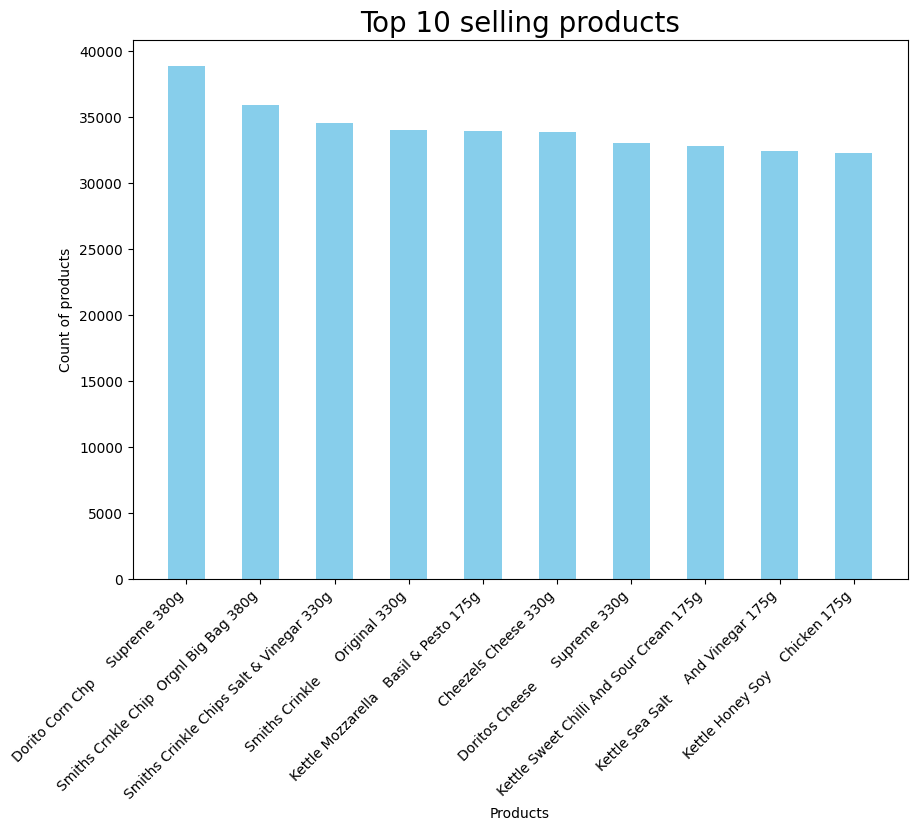

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10,7))
plt.bar(top_products['PROD_NAME'],top_products['TOT_SALES'],color='skyblue',width=0.5,)
plt.title("Top 10 selling products",size=20)
plt.xlabel("Products")
plt.ylabel("Count of products")
plt.xticks(rotation=45,ha='right')
plt.show()
plt.savefig("top_10.products.jpg",dpi=400,bbox_inches='tight')

In [ ]:
dt.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,MIDAGE SINGLES/COUPLES,Budget
3,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330,MIDAGE SINGLES/COUPLES,Budget
4,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,210,MIDAGE SINGLES/COUPLES,Budget
5,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9,150,MIDAGE SINGLES/COUPLES,Budget
6,2018-08-18,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2,210,MIDAGE SINGLES/COUPLES,Budget
7,2019-05-17,7,7215,7176,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330,MIDAGE SINGLES/COUPLES,Budget
8,2019-05-18,9,9208,8634,15,Twisties Cheese 270g,2,9.2,270,MIDAGE SINGLES/COUPLES,Budget
9,2018-08-17,13,13213,12447,92,WW Crinkle Cut Chicken 175g,1,1.7,175,MIDAGE SINGLES/COUPLES,Budget


In [ ]:
driver=dt.groupby(['LIFESTAGE'])['TOT_SALES'].sum().sort_values(ascending=False).reset_index()

In [ ]:
driver

,LIFESTAGE,TOT_SALES
0,OLDER SINGLES/COUPLES,373215.95
1,RETIREES,340282.45
2,OLDER FAMILIES,325857.05
3,YOUNG FAMILIES,292416.75
4,YOUNG SINGLES/COUPLES,242546.90
5,MIDAGE SINGLES/COUPLES,171297.35
6,NEW FAMILIES,47168.50


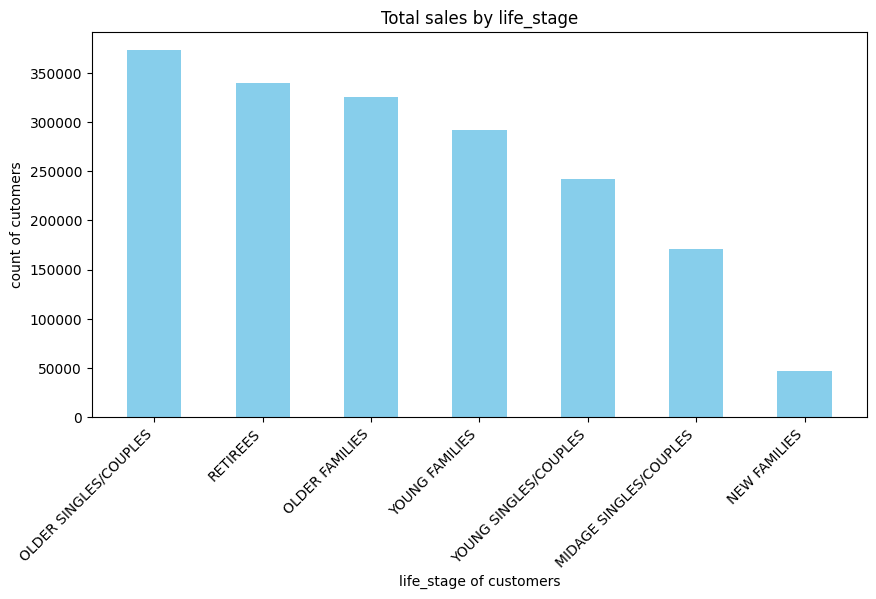

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(driver['LIFESTAGE'],driver['TOT_SALES'],color='skyblue',width=0.5)
plt.xlabel("life_stage of customers")
plt.ylabel("count of cutomers")
plt.title("Total sales by life_stage")
plt.xticks(rotation=45,ha='right')
plt.show()
plt.savefig("Total_sales.lifestage.png",dpi=400)

In [ ]:
segment_count = dt.groupby('LIFESTAGE')['TOT_SALES'].count().sort_values(ascending=False).reset_index()

In [ ]:
segment_count

,LIFESTAGE,TOT_SALES
0,OLDER SINGLES/COUPLES,50645
1,RETIREES,46318
2,OLDER FAMILIES,45015
3,YOUNG FAMILIES,40372
4,YOUNG SINGLES/COUPLES,33901
5,MIDAGE SINGLES/COUPLES,23334
6,NEW FAMILIES,6488


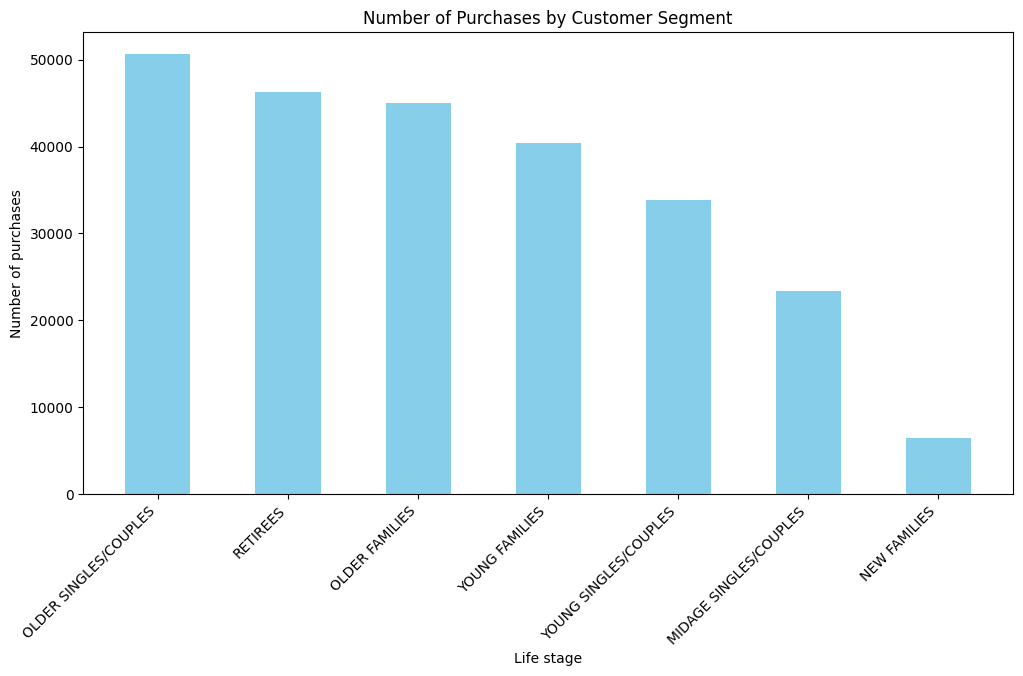

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(segment_count['LIFESTAGE'],segment_count['TOT_SALES'],color='skyblue',width=0.5)
plt.xlabel("Life stage")
plt.ylabel("Number of purchases")
plt.title("Number of Purchases by Customer Segment")
plt.xticks(rotation=45,ha='right')
plt.show()
plt.savefig("Total_purchases.segemnt.png",dpi=400)

In [ ]:
pack_pref=dt.groupby(['LIFESTAGE','PACK_SIZE'])['TOT_SALES'].sum().unstack()

In [ ]:
pack_pref

PACK_SIZE,70,90,110,125,134,135,150,160,165,170,175,180,190,200,210,220,250,270,330,380
LIFESTAGE,,,,,,,,,,,,,,,,,,,,
MIDAGE SINGLES/COUPLES,633.6,799.0,16070.2,432.6,16753.6,2461.2,27133.3,1026.0,9450.0,13486.3,46366.7,685.1,1286.1,1385.1,4219.2,660.1,2304.8,5699.4,13121.4,7323.65
NEW FAMILIES,127.2,176.8,4609.4,205.8,4898.8,709.8,7439.0,233.7,2491.0,3852.4,12693.5,167.4,301.5,359.1,1242.0,161.0,623.5,1352.4,3442.8,2081.40
OLDER FAMILIES,1464.0,2050.2,28017.4,1211.7,30229.0,4296.6,52748.4,2344.6,19800.0,26578.6,87890.8,2015.0,3199.8,3665.1,7534.8,1566.3,4661.2,9581.8,24264.9,12736.85
OLDER SINGLES/COUPLES,1382.4,1888.7,34006.2,1190.7,37366.3,5951.4,60637.7,2107.1,19867.2,30064.5,100139.1,1723.6,2964.9,3135.0,8931.6,1271.9,5499.7,11293.0,27941.4,15853.55
RETIREES,1202.4,1703.4,31224.6,995.4,34624.6,4985.4,54465.1,1692.9,18071.0,27796.8,91484.1,1407.4,2176.5,2561.2,8308.8,1131.6,5344.9,10552.4,26140.2,14413.75
YOUNG FAMILIES,1272.0,1995.8,25159.8,1024.8,27158.0,4053.0,47198.1,1924.7,17922.8,24253.8,79729.3,1639.9,2820.0,3098.9,6573.6,1320.2,3870.0,8326.0,21506.1,11569.95
YOUNG SINGLES/COUPLES,770.4,1062.5,22769.6,672.0,25108.2,3515.4,37995.7,1318.6,13218.2,19744.7,63796.9,883.5,1647.6,1803.1,6012.0,719.9,3581.9,8013.2,19066.5,10847.00


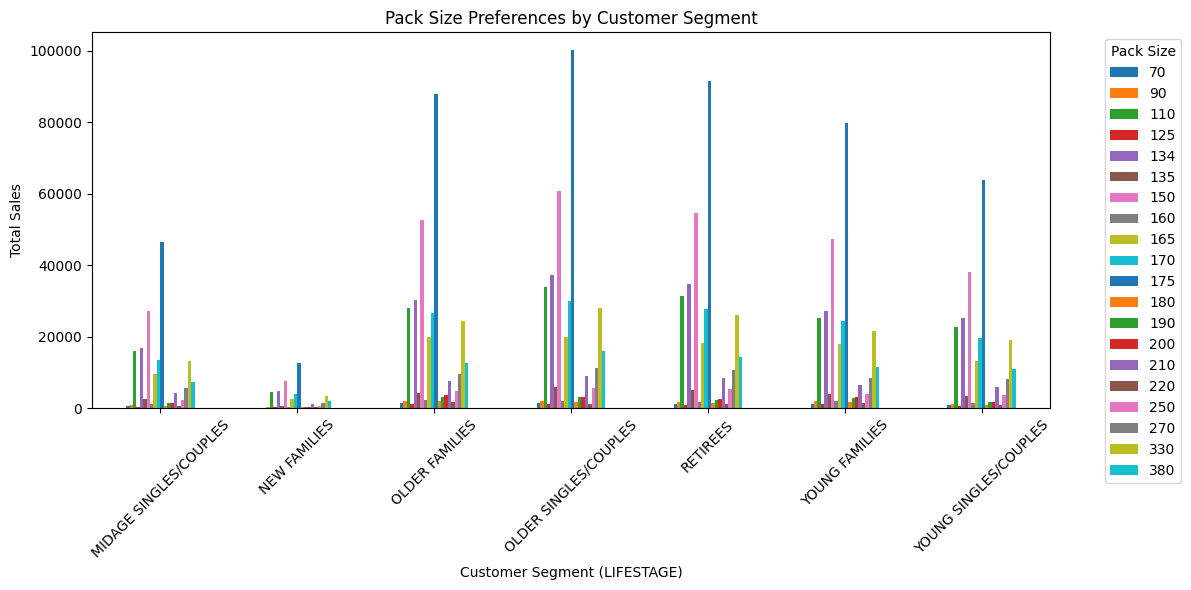

<Figure size 640x480 with 0 Axes>

In [ ]:
pack_pref.plot(kind='bar', figsize=(12,6))

plt.title('Pack Size Preferences by Customer Segment')
plt.xlabel('Customer Segment (LIFESTAGE)')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.legend(title='Pack Size', bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()
plt.savefig("packsize_prefrences.png",dpi=400)

In [ ]:
from google.colab import files
files.download("sales_customer.segemnt.jpg")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>